In [1]:
import sys
import utils_00 as gf_utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

large_data_dir = gf_utils.large_data_dir

In [ ]:
gf_dir = large_data_dir + 'gf_CL3_GapLength_HB_4plex/'
adata_path = large_data_dir + 'CL3_GapLength_HB_4plex.h5ad'

6996201 UMIs found
Collapsing UMIs across probes, 6996201 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 6959475 UMIs remaining (99.48%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 5942006 UMIs remaining (84.93%)
10894706 UMIs found
Collapsing UMIs across probes, 10894706 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 10838886 UMIs remaining (99.49%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 9019094 UMIs remaining (82.78%)
5284290 UMIs found
Collapsing UMIs across probes, 5284290 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 5247731 UMIs remaining (99.31%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcode

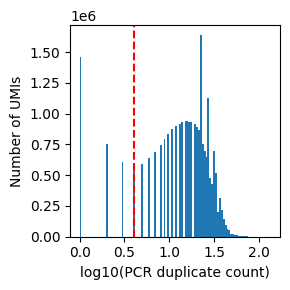

In [3]:
for lib in ['1','2','3','4']:
    probe_reads = gf_utils.get_input_probe_reads(gf_dir + 'BC' + lib + '_giftwrap/', read_threshold=0, min_percent_supporting=0.9, adata_path=adata_path, collapse_across_probes=True)
    manifest = gf_utils.get_manifest(gf_dir + 'BC' + lib + '_giftwrap/')
    ## fix expected gapfills to distinguish between NA (probe should not bind) and '' (gapfill should be 0bp)
    manifest.loc[manifest['name'].str.contains('c.') & (manifest['gapfill_from_transcriptome'].isna()) & (manifest['gapfill_start'].notna()) & (manifest['gapfill_end'].notna()),'gapfill_from_transcriptome'] = ''
    manifest.loc[manifest['name'].str.contains('0bp'),'gapfill_from_transcriptome'] = ''
    manifest.loc[manifest['name'].str.contains('0bp'),'gap_probe_sequence'] = ''

    probe_reads = probe_reads.merge(manifest[['gap_probe_sequence','gapfill_from_transcriptome','name']], left_on='probe_idx',right_index=True, how='left')
    probe_reads['probe_barcode'] = int(lib)
    if lib == '1':
        all_probe_reads = probe_reads
    else:
        all_probe_reads = pd.concat([all_probe_reads, probe_reads])


print(len(all_probe_reads), ' UMIs before filtering for read threshold')

read_threshold = 4
gf_utils.plot_reads_per_umi(probe_reads=all_probe_reads, read_threshold=read_threshold)

probe_reads = all_probe_reads.loc[all_probe_reads['pcr_duplicate_count'] > read_threshold].copy()
del all_probe_reads

print(len(probe_reads), ' UMIs remaining after filtering for read threshold:', read_threshold)


In [4]:
## load in predicted genotypes file
predicted_genotypes = pd.read_csv('../data/3cl_predicted_genotypes.csv',sep=',')

### manual changes to predicted genotypes
predicted_genotypes.loc[predicted_genotypes['name'] == 'TP53 c.405insC','name'] = 'TP53 c.407insC' ## these are the same but named differently in this panel
predicted_genotypes.loc[(predicted_genotypes['name'] == 'INSR c.1650G>A') & (predicted_genotypes['cell_type'] == 'HEL'),'genotype_from_bulk'] = 'heterozygous'
predicted_genotypes = pd.concat([predicted_genotypes, pd.DataFrame([{'name': 'BCR-ABL c.70', 'cell_type': 'K562', 'genotype_from_bulk': 'homozygous_alt'}])], ignore_index=True)
predicted_genotypes = pd.concat([predicted_genotypes, pd.DataFrame([{'name': 'BCR-ABL c.70', 'cell_type': 'HEL', 'genotype_from_bulk': 'none'}])], ignore_index=True)
predicted_genotypes = pd.concat([predicted_genotypes, pd.DataFrame([{'name': 'BCR-ABL c.70', 'cell_type': 'SET2', 'genotype_from_bulk': 'none'}])], ignore_index=True)


In [5]:
## get 0bp counts and then remove them from probe_reads
counts_0bp = probe_reads.loc[probe_reads['name'].str.contains('0bp')].groupby(['probe_idx','name','probe_barcode']).size().reset_index(name='count')
counts_0bp['gene'] = counts_0bp['name'].str.split(' ',expand=True)[0]
probe_reads = probe_reads.loc[~probe_reads['name'].str.contains('0bp')]


## find non-variant targets
probe_reads = probe_reads.merge(predicted_genotypes[['cell_type','name','genotype_from_bulk']], on = ['cell_type','name'], how='left')
all_probes = pd.Series(probe_reads['name'].unique())
non_variant_probes = all_probes[all_probes.str.split('c.', expand=True)[1].apply(lambda x: x.isdigit() if isinstance(x, str) else False)]

## subset to gapfills that are correct
probe_reads['correct'] = False
probe_reads.loc[(probe_reads['name'].isin(non_variant_probes)) & (probe_reads['gapfill'] == probe_reads['gapfill_from_transcriptome']), 'correct'] = True
probe_reads.loc[(probe_reads['genotype_from_bulk'] == 'homozygous_ref') & (probe_reads['gapfill'] == probe_reads['gapfill_from_transcriptome']), 'correct'] = True
probe_reads.loc[(probe_reads['genotype_from_bulk'] == 'homozygous_alt') & (probe_reads['gapfill'] == probe_reads['gap_probe_sequence']), 'correct'] = True
probe_reads.loc[(probe_reads['genotype_from_bulk'] == 'heterozygous') & ((probe_reads['gapfill'] == probe_reads['gap_probe_sequence']) | (probe_reads['gapfill'] == probe_reads['gapfill_from_transcriptome'])), 'correct'] = True
probe_reads = probe_reads.loc[probe_reads['correct']].reset_index(drop=True)


In [6]:
### get gap lengths and collapse to summary dataframe
probe_reads['gap_length'] = probe_reads['gapfill'].str.len()
length_counts = probe_reads.groupby(['gap_length','probe_idx','probe_barcode','name']).size().reset_index()
length_counts = length_counts.rename(columns={0:'count'})
length_counts['gene'] = length_counts['name'].str.split(' ',expand=True)[0]
length_counts = length_counts.merge(counts_0bp[['gene','probe_barcode','count']], on=['gene','probe_barcode'], how='left', suffixes=('_gap','_0bp'))
length_counts['count_0bp'] = length_counts['count_0bp'].fillna(0)
length_counts['counts_per_0bp'] = length_counts['count_gap'] / length_counts['count_0bp']

length_counts.to_csv('../output/gap_length_counts_no_betaine.csv',index=False)